# Day 7：Business EDA & Statistical Thinking（Data Scientist Version）⭐⭐⭐⭐⭐

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Matplotlib:", plt.matplotlib.__version__)
print("Seaborn:", sns.__version__)

NumPy: 2.5.0
Pandas: 3.0.3
Matplotlib: 3.11.0
Seaborn: 0.13.2


In [3]:
import seaborn as sns

df = sns.load_dataset("titanic")

df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


## Project 1：Titanic Business Case

### Business Question : 女性真的比較容易生還嗎？

#### Step 1：提出研究問題

女性是否比男性更容易生還？

H0(虛無假設): 女性與男性的生存率沒有顯著差異。

H1(對立假設): 女性的生存率高於男性。


##### 研究問題：女性和男性的生還率是否有明顯差異？女性是否有較大的生還率？
Does passenger sex significantly affect survival probability?

#### Step 2：思考需要哪些欄位

sex (female / male) >> 類別

survived (0 / 1) >>類別+數字

df["survived].mean() >>可得生還率

近一步分析混雜因子:

1. 不同艙等:可能在first class有較高的生還率，而剛好有較多女性在此空間。 是不是不是因為女性，而是因為女性比較多在頭等艙？

2. 不同票價:較高票價可以在first class，也可能剛好女性較多，有較高的生還率。

3. 不同年齡間距:可能採取老弱婦孺優先救難策略，符合其中標中的女性較多。

提問:


如果女性生存率比較高，是不是所有艙等都是這樣？

df.groupby(["class"],["sex"])["survuved"].mean()

即使控制艙等後，女性仍然有較高生存率。


#### Step 3：EDA 

哪些圖最適合？

類別+數字 想看生還率差異 >> barplot  

計算兩個性別的生死人數 >>　countplot


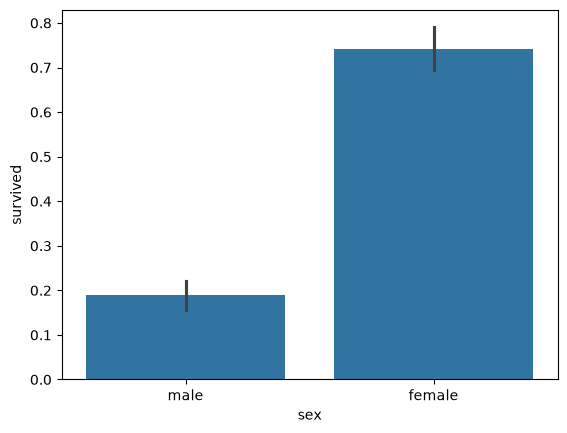

In [20]:
sns.barplot(
    x="sex",
    y="survived",
    data=df
)
plt.show()

#### 說明:女性生存率遠高於男性。

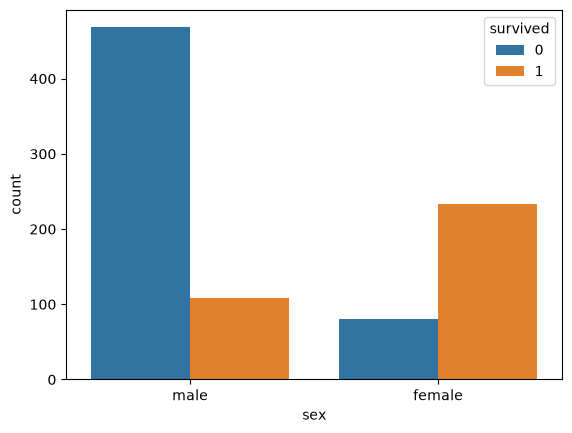

In [21]:
sns.countplot(
    x="sex",
    hue="survived",
    data=df
)
plt.show()

##### 顯示每一組有多少人？（Count）

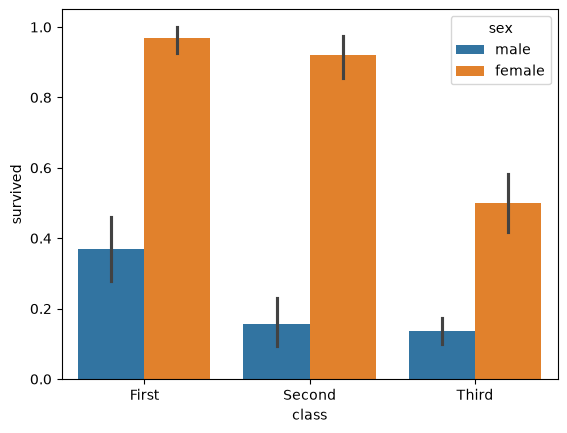

In [17]:
sns.barplot(x= "class", y="survived", hue = "sex", data = df)
plt.show()

#### 即使在相同艙等中，女性的生存率仍然高於男性。

#### Step 4：Group Analysis

In [4]:
#看各組生還率
df.groupby("sex")["survived"].mean()

sex
female    0.742038
male      0.188908
Name: survived, dtype: float64

In [7]:
df.groupby(["sex","class"])["survived"].mean()

sex     class 
female  First     0.968085
        Second    0.921053
        Third     0.500000
male    First     0.368852
        Second    0.157407
        Third     0.135447
Name: survived, dtype: float64

1. 生存率讀論有無分艙等皆是女性高於男性
2. 在兩格性別中，first class都是生存率最高的艙等，其次是second，最後是third。

#### Step 5：Statistical Thinking

sex：類別

survived：雖然用 0/1 表示，但它代表的是是否生還（Yes/No），本質上是二元類別（Binary Categorical）。
##### 方法一：Chi-square Test（★★★★★）
研究:性別是否與生存有關？

使用資料：
|        | Survived | Died |
| ------ | -------: | ---: |
| Female |      233 |   81 |
| Male   |      109 |  468 |


| 問題                       | 建議統計方法                |
| ------------------------ | --------------------- |
| 性別是否影響生存？（兩個都是類別）        | ✅ Chi-square Test     |
| 男女性生存率（把 survived 當 0/1） | 可以 t-test，但較少作為首選     |
| 比較男女年齡是否不同               | t-test                |
| 比較男女票價是否不同               | t-test / Mann-Whitney |


In [24]:
!pip install scipy
import scipy
print(scipy.__version__)

1.18.0


In [25]:

from scipy.stats import chi2_contingency

table = pd.crosstab(df["sex"], df["survived"])

chi2, p, dof, expected = chi2_contingency(table)

print(table)
print("Chi-square:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)
print(expected)

survived    0    1
sex               
female     81  233
male      468  109
Chi-square: 260.71702016732104
p-value: 1.1973570627755645e-58
Degrees of freedom: 1
[[193.47474747 120.52525253]
 [355.52525253 221.47474747]]


Expected table:如果性別完全不影響生存，我們原本應該看到多少人？
| Sex    |     死亡(期望) |     生還(期望) |
| ------ | ---------: | ---------: |
| Female | **193.47** | **120.53** |
| Male   | **355.53** | **221.47** |

卡方檢定:

每一格的「實際值」和「期望值」差多少，把差距平方後再依照期望值做標準化，最後全部加總。

Expected Frequency = 在「兩個變數完全沒有關聯」的世界裡，我們預期每一格應該出現的人數。

卡方檢定意義:

實際觀察到的人數，是否和這個「沒有關聯」的世界差太多？

1. Chi-square = 260.72 >> Observed 與 Expected 差距非常大。
##### 性別與生存之間的關聯非常明顯。
2. p = 1.19 × 10⁻⁵⁸ >> 幾乎=0 

因為 p << 0.05

所以：Reject H₀（拒絕虛無假設）

##### 性別與 Titanic 生存具有顯著關聯。

#### Business Insight

分析結果顯示，女性乘客的生存率約為 74.2%，遠高於男性乘客的 18.9%。

卡方檢定結果（χ² = 260.72，p < 0.001）顯示，性別與生存狀態之間存在高度顯著的統計關聯。

因此，在 Titanic 事件中，女性乘客具有明顯較高的生存機率。



近一步用 Cramér's V 鑑測關聯性的強度

In [26]:
import numpy as np

chi2 = 260.71702016732104
n = 891
k = min(table.shape)

cramers_v = np.sqrt(chi2 / (n * (k - 1)))

print(cramers_v)

0.5409359434469282


| Cramér's V | 關聯強度 |
| ---------- | ---- |
| <0.10      | 幾乎沒有 |
| 0.10~0.30  | 弱    |
| 0.30~0.50  | 中等   |
| >0.50      | 強    |


Strong Association（強關聯）

和 p-value 一起看

你的結果：

Chi-square = 260.72
p < 0.001
Cramér's V = 0.541

代表：

✅ 有顯著差異

而且：

✅ 關聯強度也很高

這兩件事要一起寫。

Chi-square analysis revealed a significant association between passenger sex and survival (χ² = 260.72, p < 0.001). The effect size measured by Cramér's V was 0.541, indicating a strong association between sex and survival.

卡方檢定顯示性別與生存具有高度顯著的統計關聯（χ² = 260.72，p < 0.001），且 Cramér's V = 0.541，代表兩者具有強烈的關聯性。女性乘客的生存率（74.2%）明顯高於男性乘客（18.9%），因此性別是 Titanic 生存分析中最重要的影響因素之一。

# Project 2：Titanic Business Case

## Business Question
    第一艙真的比較安全嗎？


研究問題: 第一艙是否比較安全?

H0:第一艙與其他艙等的生存率沒有差異。

H1:第一艙的生存率明顯高於其他艙等的生存率。

需使用的欄位: survived(類別) class(類別) 

EDA: 